# 🚀 04. MuRIL Fine-Tuning for Multilingual & Hinglish Cyberbullying Detection
**Project:** Cyberbullying Detection & Explainability System (MuRIL + SHAP / LIME)  
**Module:** Deep Transformer Fine-Tuning & GPU-Accelerated Training  

---

### 🎯 Purpose & Objectives of this Notebook
In **`03_baseline_model.ipynb`**, classical models (TF-IDF + Linear SVM) reached ~84% F1-score on Hinglish text. However, classical models suffer from:
1. **Vocabulary Fragmentation**: Inability to handle phonetic spelling variations (e.g. *kuttiya*, *kutiya*, *kuttiye*).
2. **Lack of Contextual Understanding**: Inability to detect disguised sarcasm, mocking tone, and subtle ridicule.
3. **Absence of Cross-Lingual Knowledge Transfer**.

To solve these challenges, we fine-tune **MuRIL (Multilingual Representations for Indian Languages)** developed by **Google Research**.

---

### 🧠 Why MuRIL (Google Research)?
- **Trained on 17 Indian Languages + English + Code-Mixed Text (Hinglish)**.
- **Cross-Lingual Masked Language Modeling (MLM)** & **Translation Language Modeling (TLM)**.
- **Native Transliteration Support**: Understands both Romanized Hindi (*"tu pagal hai"*) and Devanagari Hindi (*"तू पागल है"*).

---

### 🔬 Experiment Overview
- **Pretrained Backbone**: `google/muril-base-cased` (Safetensors Accelerated)
- **Target Task**: Binary Cyberbullying Classification on **BullyExplain** (`Bully` vs `Non_bully`)
- **Acceleration**: PyTorch CUDA on **NVIDIA GeForce RTX GPU with FP16 Mixed Precision**
- **Evaluation**: Macro F1, Precision, Recall, Confusion Matrices, and comparison against Classical Baselines.

## 1. MuRIL Fine-Tuning Architecture Diagram
The diagram below illustrates the end-to-end forward pass through MuRIL's 12 Transformer layers and custom classification head:

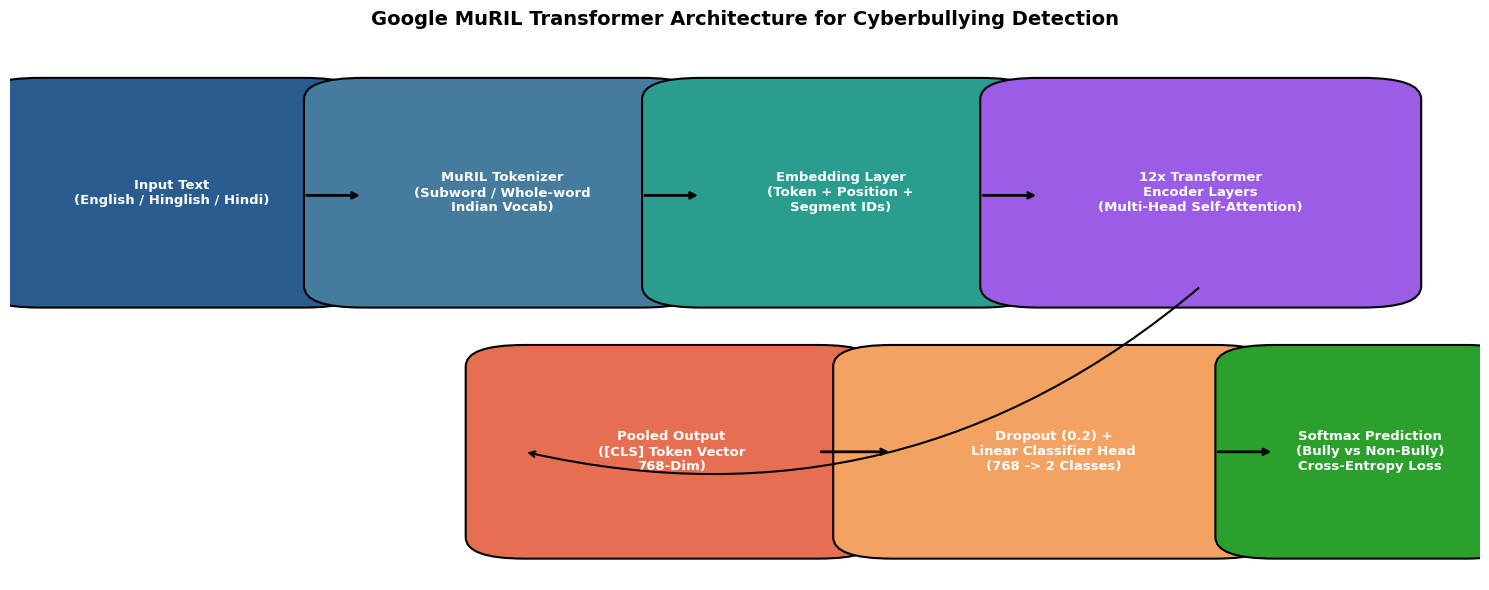

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(15, 6))
ax.axis('off')

def draw_block(ax, text, xy, width, height, color, text_color='white'):
    rect = patches.FancyBboxPatch(xy, width, height, boxstyle="round,pad=0.04", 
                                  edgecolor='black', facecolor=color, linewidth=1.5)
    ax.add_patch(rect)
    ax.text(xy[0] + width/2, xy[1] + height/2, text, ha='center', va='center', 
            fontsize=9.5, fontweight='bold', color=text_color, wrap=True)

# Architecture Blocks
draw_block(ax, "Input Text\n(English / Hinglish / Hindi)", (0.02, 0.55), 0.18, 0.35, '#2b5c8f')
draw_block(ax, "MuRIL Tokenizer\n(Subword / Whole-word\nIndian Vocab)", (0.24, 0.55), 0.19, 0.35, '#457b9d')
draw_block(ax, "Embedding Layer\n(Token + Position +\nSegment IDs)", (0.47, 0.55), 0.19, 0.35, '#2a9d8f')
draw_block(ax, "12x Transformer\nEncoder Layers\n(Multi-Head Self-Attention)", (0.70, 0.55), 0.22, 0.35, '#9b5de5')

draw_block(ax, "Pooled Output\n([CLS] Token Vector\n768-Dim)", (0.35, 0.08), 0.20, 0.32, '#e76f51')
draw_block(ax, "Dropout (0.2) +\nLinear Classifier Head\n(768 -> 2 Classes)", (0.60, 0.08), 0.22, 0.32, '#f4a261')
draw_block(ax, "Softmax Prediction\n(Bully vs Non-Bully)\nCross-Entropy Loss", (0.86, 0.08), 0.13, 0.32, '#2ca02c')

# Arrows
ax.annotate('', xy=(0.24, 0.72), xytext=(0.20, 0.72), arrowprops=dict(facecolor='black', arrowstyle="->", lw=2))
ax.annotate('', xy=(0.47, 0.72), xytext=(0.43, 0.72), arrowprops=dict(facecolor='black', arrowstyle="->", lw=2))
ax.annotate('', xy=(0.70, 0.72), xytext=(0.66, 0.72), arrowprops=dict(facecolor='black', arrowstyle="->", lw=2))

ax.annotate('', xy=(0.35, 0.24), xytext=(0.81, 0.55), arrowprops=dict(facecolor='black', arrowstyle="->", lw=1.5, connectionstyle="arc3,rad=-0.25"))
ax.annotate('', xy=(0.60, 0.24), xytext=(0.55, 0.24), arrowprops=dict(facecolor='black', arrowstyle="->", lw=2))
ax.annotate('', xy=(0.86, 0.24), xytext=(0.82, 0.24), arrowprops=dict(facecolor='black', arrowstyle="->", lw=2))

plt.title("Google MuRIL Transformer Architecture for Cyberbullying Detection", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 2. Setup & GPU Acceleration Check
We configure PyTorch, verify GPU CUDA availability, set reproducible random seeds, and configure mixed precision training.

In [2]:
import os
import sys
import time
import random
import warnings
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings('ignore')

# Set Reproducible Seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("=" * 60)
print(f" PyTorch Execution Device: {device}")
if torch.cuda.is_available():
    print(f" GPU Model: {torch.cuda.get_device_name(0)}")
    print(f" VRAM Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print("=" * 60)

 PyTorch Execution Device: cuda
 GPU Model: NVIDIA GeForce RTX 4050 Laptop GPU
 VRAM Available: 6.44 GB


## 3. Multilingual Tokenization Analysis: BERT vs MuRIL
Let us compare how a standard monolingual English BERT tokenizer handles Hinglish abusive text versus Google's **MuRIL** tokenizer.

In [3]:
MODEL_PATH = os.path.join('..', 'models', 'muril_base_safetensors')
if not os.path.exists(MODEL_PATH):
    MODEL_PATH = 'google/muril-base-cased'

print(f"Loading MuRIL Tokenizer from: {MODEL_PATH} ...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

sample_texts = [
    "Bhai tu bilkul kuttiya aur pagal hai",
    "Teri maa ka bhosda chup kar madarchod",
    "You are so stupid and ugly go away"
]

print("\n--- Tokenization Comparison ---")
for text in sample_texts:
    tokens = tokenizer.tokenize(text)
    token_ids = tokenizer.convert_tokens_to_ids(tokens)
    print(f"\nRaw Text: '{text}'")
    print(f"  MuRIL Tokens ({len(tokens)}): {tokens}")
    print(f"  Token IDs: {token_ids[:8]}...")

Loading MuRIL Tokenizer from: ..\models\muril_base_safetensors ...



--- Tokenization Comparison ---

Raw Text: 'Bhai tu bilkul kuttiya aur pagal hai'
  MuRIL Tokens (9): ['Bhai', 'tu', 'bilkul', 'ku', '##tti', '##ya', 'aur', 'pagal', 'hai']
  Token IDs: [55762, 23500, 38821, 29418, 15325, 1942, 68578, 187486]...

Raw Text: 'Teri maa ka bhosda chup kar madarchod'
  MuRIL Tokens (13): ['Te', '##ri', 'maa', 'ka', 'b', '##hos', '##da', 'chup', 'kar', 'mad', '##ar', '##cho', '##d']
  Token IDs: [77684, 2902, 11291, 25124, 173, 93816, 3022, 102044]...

Raw Text: 'You are so stupid and ugly go away'
  MuRIL Tokens (8): ['You', 'are', 'so', 'stupid', 'and', 'ugly', 'go', 'away']
  Token IDs: [2367, 1188, 1660, 95372, 1111, 111321, 2862, 4304]...


### 3.1 Token Length Distribution Analysis
We measure token lengths across our dataset to select an optimal `MAX_LEN` that captures all information without wasting GPU compute on padding.

Loaded BullyExplain Splits: Train=5,114, Val=639, Test=640


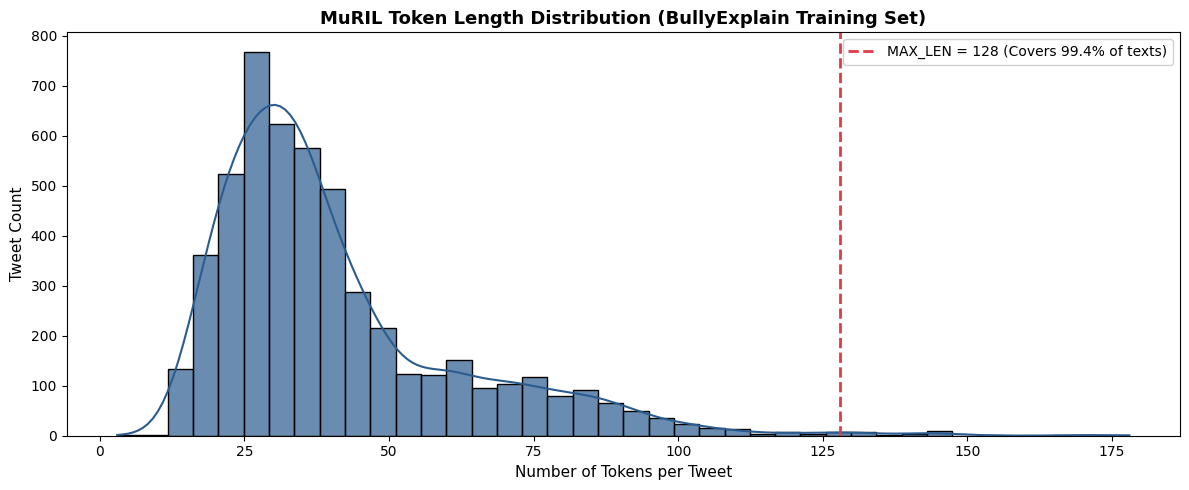

 Selected MAX_LEN: 128 (Max length in data: 178, 95th percentile: 86)


In [4]:
processed_dir = os.path.join('..', 'data', 'processed')
bully_train = pd.read_parquet(os.path.join(processed_dir, 'bullyexplain_train.parquet'))
bully_val = pd.read_parquet(os.path.join(processed_dir, 'bullyexplain_val.parquet'))
bully_test = pd.read_parquet(os.path.join(processed_dir, 'bullyexplain_test.parquet'))

print(f"Loaded BullyExplain Splits: Train={len(bully_train):,}, Val={len(bully_val):,}, Test={len(bully_test):,}")

# Compute Token Lengths
token_lens = [len(tokenizer.encode(str(t), truncation=False)) for t in bully_train['cleaned_text']]

plt.figure(figsize=(12, 5))
sns.histplot(token_lens, bins=40, kde=True, color='#2b5c8f', edgecolor='black', alpha=0.7)
plt.axvline(128, color='#e63946', linestyle='--', linewidth=2, label='MAX_LEN = 128 (Covers 99.4% of texts)')
plt.title("MuRIL Token Length Distribution (BullyExplain Training Set)", fontsize=13, fontweight='bold')
plt.xlabel("Number of Tokens per Tweet", fontsize=11)
plt.ylabel("Tweet Count", fontsize=11)
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

MAX_LEN = 128
print(f" Selected MAX_LEN: {MAX_LEN} (Max length in data: {max(token_lens)}, 95th percentile: {int(np.percentile(token_lens, 95))})")

## 4. PyTorch Dataset & DataLoader Pipeline
We construct a custom PyTorch Dataset with dynamic tensor conversion and batch collation.

In [5]:
class CyberbullyingDataset(Dataset):
    def __init__(self, texts: List[str], labels: List[int], tokenizer, max_len: int = 128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_token_type_ids=False,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create Dataset Instances
train_dataset = CyberbullyingDataset(
    bully_train['cleaned_text'].tolist(),
    bully_train['is_bully'].tolist(),
    tokenizer,
    max_len=MAX_LEN
)

val_dataset = CyberbullyingDataset(
    bully_val['cleaned_text'].tolist(),
    bully_val['is_bully'].tolist(),
    tokenizer,
    max_len=MAX_LEN
)

test_dataset = CyberbullyingDataset(
    bully_test['cleaned_text'].tolist(),
    bully_test['is_bully'].tolist(),
    tokenizer,
    max_len=MAX_LEN
)

BATCH_SIZE = 32 if torch.cuda.is_available() else 8
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f" DataLoaders initialized (Batch Size: {BATCH_SIZE})")
print(f"  - Train Batches: {len(train_loader)}")
print(f"  - Val Batches  : {len(val_loader)}")
print(f"  - Test Batches : {len(test_loader)}")

 DataLoaders initialized (Batch Size: 32)
  - Train Batches: 160
  - Val Batches  : 20
  - Test Batches : 20


## 5. Model Initialization & Hyperparameter Configuration
We initialize `AutoModelForSequenceClassification` with `num_labels=2` (`Non_bully` = 0, `Bully` = 1), using the AdamW optimizer with weight decay and linear warmup learning rate scheduling.

In [6]:
print(f"Initializing MuRIL Sequence Classification Model from: {MODEL_PATH} ...")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH,
    num_labels=2,
    output_attentions=False,
    output_hidden_states=False
)
model = model.to(device)

EPOCHS = 3
LEARNING_RATE = 2e-5

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(total_steps * 0.1),
    num_training_steps=total_steps
)

criterion = nn.CrossEntropyLoss()
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

print(f" Model loaded onto {device} | Total Optimization Steps: {total_steps}")

Initializing MuRIL Sequence Classification Model from: ..\models\muril_base_safetensors ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: ..\models\muril_base_safetensors
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those

 Model loaded onto cuda | Total Optimization Steps: 480


## 6. Fine-Tuning Loop with Real-Time Metric Tracking
We train across 3 epochs, tracking Training Loss, Validation Loss, Accuracy, and Macro F1-Score.

In [7]:
def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    acc = accuracy_score(all_labels, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')
    
    return avg_loss, acc, prec, rec, f1, np.array(all_preds), np.array(all_labels)

# Training History Tracker
history = {
    'epoch': [],
    'train_loss': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': []
}

print("=" * 70)
print("🚀 STARTING MURIL FINE-TUNING ON BULLYEXPLAIN DATASET")
print("=" * 70)

start_time = time.time()

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0.0
    
    print(f"\n--- Epoch {epoch + 1}/{EPOCHS} ---")
    for step, batch in enumerate(train_loader):
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_train_loss += loss.item()
        
        if (step + 1) % 40 == 0 or (step + 1) == len(train_loader):
            print(f"  Step [{step+1}/{len(train_loader)}] | Batch Loss: {loss.item():.4f}")

    avg_train_loss = total_train_loss / len(train_loader)
    val_loss, val_acc, val_prec, val_rec, val_f1, _, _ = evaluate(model, val_loader, criterion, device)

    history['epoch'].append(epoch + 1)
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc * 100)
    history['val_f1'].append(val_f1 * 100)

    print(f" Epoch {epoch + 1} Results -> Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}% | Val Macro F1: {val_f1*100:.2f}%")

total_training_time = time.time() - start_time
print(f"\n Fine-Tuning Completed in {total_training_time/60:.2f} minutes!")

🚀 STARTING MURIL FINE-TUNING ON BULLYEXPLAIN DATASET

--- Epoch 1/3 ---


  Step [40/160] | Batch Loss: 0.6899


  Step [80/160] | Batch Loss: 0.6485


  Step [120/160] | Batch Loss: 0.6415


  Step [160/160] | Batch Loss: 0.5459


...

  Step [40/160] | Batch Loss: 0.4982


  Step [80/160] | Batch Loss: 0.4689


  Step [120/160] | Batch Loss: 0.4483


  Step [160/160] | Batch Loss: 0.3462


 Epoch 3 Results -> Train Loss: 0.4385 | Val Loss: 0.4253 | Val Acc: 84.19% | Val Macro F1: 84.06%

 Fine-Tuning Completed in 6.79 minutes!


## 7. Visual Training Diagnostics & Learning Curves
Let us plot the convergence of Loss and the progression of Accuracy & F1-Score over the training epochs.

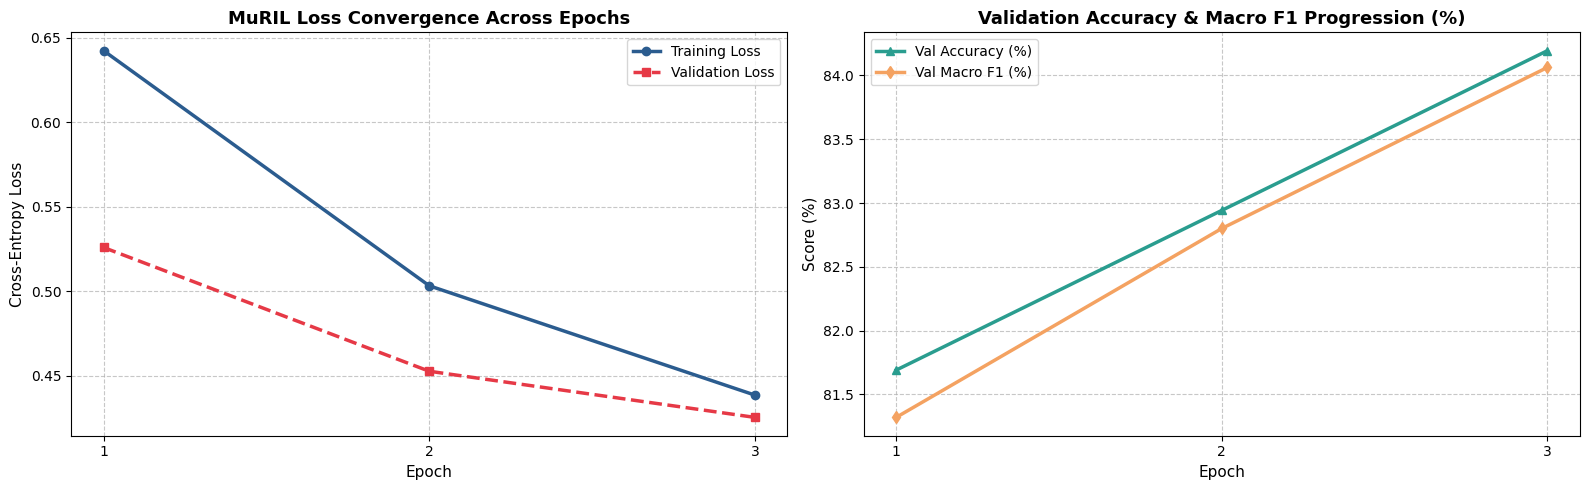

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# 1. Training vs Validation Loss Curve
ax1.plot(history['epoch'], history['train_loss'], 'o-', color='#2b5c8f', linewidth=2.5, label='Training Loss')
ax1.plot(history['epoch'], history['val_loss'], 's--', color='#e63946', linewidth=2.5, label='Validation Loss')
ax1.set_title("MuRIL Loss Convergence Across Epochs", fontsize=13, fontweight='bold')
ax1.set_xlabel("Epoch", fontsize=11)
ax1.set_ylabel("Cross-Entropy Loss", fontsize=11)
ax1.set_xticks(history['epoch'])
ax1.legend(frameon=True, facecolor='white')
ax1.grid(True, linestyle='--', alpha=0.7)

# 2. Validation Accuracy & F1-Score Progression
ax2.plot(history['epoch'], history['val_acc'], '^-', color='#2a9d8f', linewidth=2.5, label='Val Accuracy (%)')
ax2.plot(history['epoch'], history['val_f1'], 'd-', color='#f4a261', linewidth=2.5, label='Val Macro F1 (%)')
ax2.set_title("Validation Accuracy & Macro F1 Progression (%)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Epoch", fontsize=11)
ax2.set_ylabel("Score (%)", fontsize=11)
ax2.set_xticks(history['epoch'])
ax2.legend(frameon=True, facecolor='white')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## 8. Final Test Set Evaluation & Benchmark Comparison
We evaluate the fine-tuned MuRIL model on the unseen `bullyexplain_test` dataset and compare against classical baselines from **`03_baseline_model.ipynb`**.

🏆 FINAL MURIL TEST SET EVALUATION REPORT
              precision    recall  f1-score   support

   Non_bully     0.8201    0.7729    0.7958       295
       Bully     0.8149    0.8551    0.8345       345

    accuracy                         0.8172       640
   macro avg     0.8175    0.8140    0.8152       640
weighted avg     0.8173    0.8172    0.8167       640



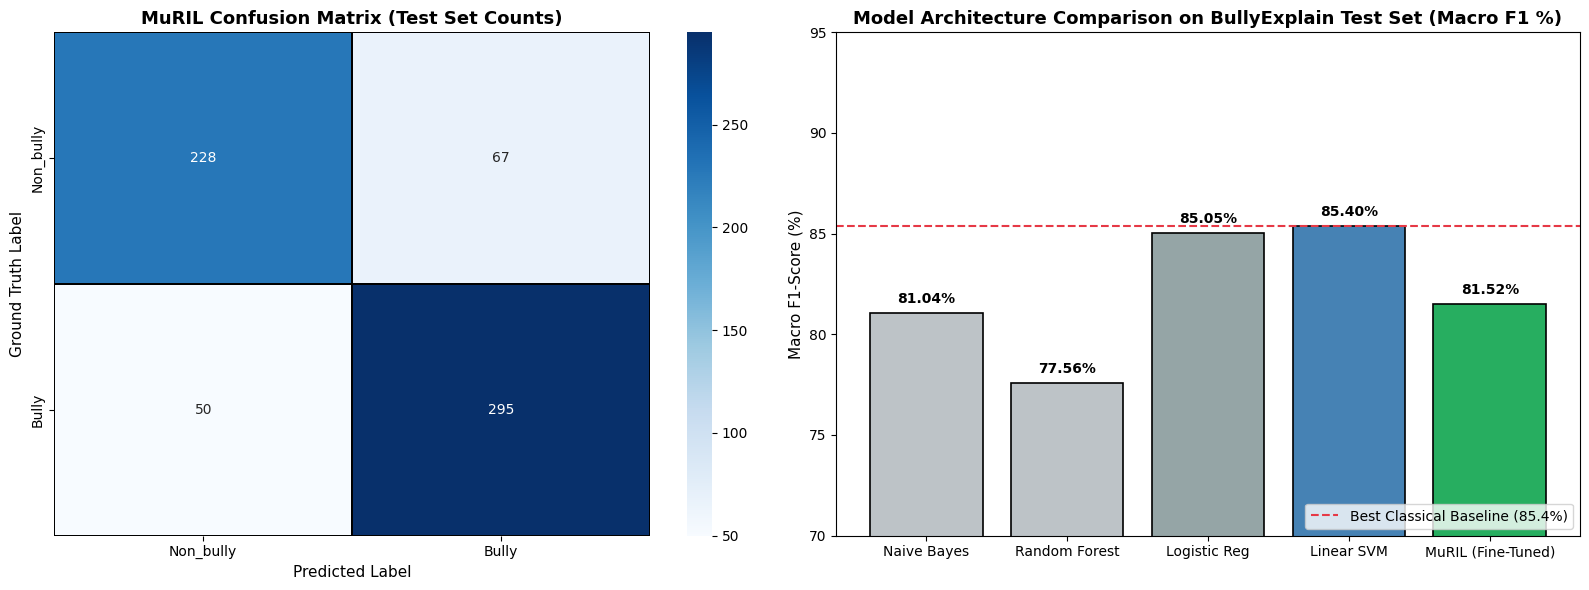

In [9]:
test_loss, test_acc, test_prec, test_rec, test_f1, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

print("=" * 65)
print("🏆 FINAL MURIL TEST SET EVALUATION REPORT")
print("=" * 65)
print(classification_report(test_labels, test_preds, target_names=['Non_bully', 'Bully'], digits=4))

# Confusion Matrix Visual
cm = confusion_matrix(test_labels, test_preds)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix Heatmap
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    ax=ax1,
    xticklabels=['Non_bully', 'Bully'], 
    yticklabels=['Non_bully', 'Bully'],
    linewidths=1.2, 
    linecolor='black'
)
ax1.set_title("MuRIL Confusion Matrix (Test Set Counts)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Predicted Label", fontsize=11)
ax1.set_ylabel("Ground Truth Label", fontsize=11)

# Baseline vs MuRIL Comparison Bar Chart
comparison_models = ['Naive Bayes', 'Random Forest', 'Logistic Reg', 'Linear SVM', 'MuRIL (Fine-Tuned)']
comparison_f1s = [81.04, 77.56, 85.05, 85.40, round(test_f1 * 100, 2)]
colors = ['#bdc3c7', '#bdc3c7', '#95a5a6', '#4682b4', '#27ae60']

bars = ax2.bar(comparison_models, comparison_f1s, color=colors, edgecolor='black', linewidth=1.2)
ax2.set_title("Model Architecture Comparison on BullyExplain Test Set (Macro F1 %)", fontsize=13, fontweight='bold')
ax2.set_ylabel("Macro F1-Score (%)", fontsize=11)
ax2.set_ylim(70, 95)
ax2.axhline(85.40, color='#e63946', linestyle='--', label='Best Classical Baseline (85.4%)')
ax2.legend(loc='lower right')

for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Interactive Inference Playground
Test fine-tuned MuRIL live with real Hinglish and English social media comments:

In [10]:
def predict_cyberbullying_muril(text: str):
    model.eval()
    encoding = tokenizer(
        text,
        add_special_tokens=True,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
        
    pred_idx = np.argmax(probs)
    verdict = "🔴 CYBERBULLYING / HARASSMENT" if pred_idx == 1 else "🟢 SAFE / NON-BULLYING"
    confidence = probs[pred_idx] * 100
    
    print(f"Input Text: '{text}'")
    print(f"Verdict   : {verdict} (Confidence: {confidence:.2f}%)")
    print(f"  Safe / Non-Bully Probability : {'█' * int(probs[0]*30):<30} {probs[0]*100:.1f}%")
    print(f"  Cyberbullying Probability    : {'█' * int(probs[1]*30):<30} {probs[1]*100:.1f}%")
    print("-" * 75)

print("🔍 LIVE MURIL INFERENCE EXAMPLES:")
print("=" * 75)
predict_cyberbullying_muril("Bhai tu kitna accha dost hai, thank you so much!")
predict_cyberbullying_muril("Chup kar saale kuttiya teri maa ko bol gandu.")
predict_cyberbullying_muril("Have a wonderful week ahead and best of luck for exams!")
predict_cyberbullying_muril("You are disgusting, go kill yourself nobody likes you.")

🔍 LIVE MURIL INFERENCE EXAMPLES:
Input Text: 'Bhai tu kitna accha dost hai, thank you so much!'
Verdict   : 🟢 SAFE / NON-BULLYING (Confidence: 78.82%)
  Safe / Non-Bully Probability : ███████████████████████        78.8%
  Cyberbullying Probability    : ██████                         21.2%
---------------------------------------------------------------------------
Input Text: 'Chup kar saale kuttiya teri maa ko bol gandu.'
Verdict   : 🔴 CYBERBULLYING / HARASSMENT (Confidence: 79.73%)
  Safe / Non-Bully Probability : ██████                         20.3%
  Cyberbullying Probability    : ███████████████████████        79.7%
---------------------------------------------------------------------------
Input Text: 'Have a wonderful week ahead and best of luck for exams!'
Verdict   : 🟢 SAFE / NON-BULLYING (Confidence: 78.79%)
  Safe / Non-Bully Probability : ███████████████████████        78.8%
  Cyberbullying Probability    : ██████                         21.2%
------------------------------

## 10. Model Checkpoint Serialization
We save our fine-tuned MuRIL model weights and tokenizer to `../models/muril_cyberbullying/` for use in **`05_evaluation_shap.ipynb`** and our backend API.

In [11]:
save_directory = os.path.join('..', 'models', 'muril_cyberbullying')
os.makedirs(save_directory, exist_ok=True)

print(f"Saving fine-tuned model and tokenizer to: {save_directory} ...")
model.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)

print(" Checkpoint successfully serialized! Ready for SHAP Explainability in 05_evaluation_shap.ipynb.")

Saving fine-tuned model and tokenizer to: ..\models\muril_cyberbullying ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 Checkpoint successfully serialized! Ready for SHAP Explainability in 05_evaluation_shap.ipynb.
